# Data analysis code for: graphs on card ranking for different explanation goals

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# global variables on cards
card_suppli = ['input', 'output', 'prior', 'performance']
card_feature = ['fa', 'fs', 'fi', 'ir', 'irc', 'ircs']
card_example = ['se', 'te', 'ce', 'ceh', 'cet']
card_rule = ['rt', 'dt', 'df']
card_all = card_suppli + card_feature + card_example + card_rule + ['wc']
card_col = ['1st', '2nd', '3rd', '4th', '5th', '6th', '7th', '8th', '9th', '10th', '11th', '12th', '13th']
card_rank = ['fa', 'fs', 'fi'] + ['se', 'te', 'ce'] + card_rule + card_suppli
purpose_col_seq=['trust', 'safe', 'bias', 'unexpect', 'expected', 'differentiate', 'learning', 'control', 'communicate', 'report', 'multi']

rank_weights = [10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 1, 1, 1]
even_weights = [1] * 13

orange = ['#F5A623', '#FFCC77']
orange2 = ['#F57323', '#FFAB77']

blue = ['#4A90E2', '#B9D7FA']
blue2 = ['#6354e5', '#C4BEFA']

def generate_rank(row):
    # for row in df, convert card_col to card_rank
#     rank = row[card_col]
    card_dict = {card: 0 for card in card_rank}
    for i in range(len(card_col)):
        if type(row[card_col[i]])==str:
            card_list = row[card_col[i]].split()
            card_list = [c.strip('@').lower() for c in card_list]
            for card in card_list:
                if card=='x' or card=='none' or card=='wc':
                    pass
                elif card in card_dict:
                    card_dict[card] = i+1
                elif card=='ir' or card=='irc' or card=='ircs':
                    if card_dict['fa'] != 0:
                        card_dict['fa'] = min(i+1, card_dict['fa'])
                    else:
                        card_dict['fa'] = i+1
                elif card == 'cet' or card == 'ceh':
                    if card_dict['ce'] != 0:
                        card_dict['ce'] = min(i+1, card_dict['ce'])
                    else:
                        card_dict['ce'] = i+1
                else:
                    print(card)
    row = row.append(pd.Series(card_dict), ignore_index=False)
    return row

df = pd.read_csv('../EUCA_quantitative_dataset/ExplanationFormRanking.csv')
df = df.rename(columns={'Index':'participant', "accept to use AI? trust it?": "accept", "require explanation? (yes/no/x(not asked))": "require"})
# get rid of rows where 'case' is nan, missing data
df = df[df['case'].notnull() & df['accept'].notnull() & df['require'].notnull() & df['1st'].notnull()]
df_l = df[df['case'].notnull() & df['1st'].notnull()]
print(df.shape, df_l.shape) # make sure no data in ranking missed
# extract task and xai purpose
df[['task', 'purpose', 'purpose2', 'purpose3']] = df['case'].str.strip('#').str.lower().str.split(pat='-', expand=True)
# check if every participant have entry
print(df['participant'].value_counts().sort_index())

# count valid responses (no 'x' in 'accept', 'require', 
# 'cards fulfill requirement? (y/n/partial/x(not asked)/black:accept blackbox AI and not require explaination)', '1st')
non_empty_col = ['accept', 'require', 'cards fulfill requirement? (y/n/partial/x(not asked)/black:accept blackbox AI and not require explaination)', '1st']
df[(df[non_empty_col[0]]=='x') & (df[non_empty_col[1]]=='x') & (df[non_empty_col[2]]=='x') & (df[non_empty_col[3]]=='x' )]

(309, 20) (309, 20)
P01    25
P02    15
P03    10
P04    10
P05    10
P06    12
P07    10
P08    14
P09    10
P10    10
P11    10
P12    10
P13     8
P14    10
P15     5
P16    12
P17    13
P18     5
P19    10
P20     5
P21     5
P22    10
P23     9
P24    10
P25    10
P26    11
P27     5
P28     5
P29    10
P30     5
P31    10
P32     5
Name: participant, dtype: int64


,participant,case,accept,require,1st round: specific explanation,2nd round: Comments on card sorting choices,cards fulfill requirement? (y/n/partial/x(not asked)/black:accept blackbox AI and not require explaination),1st,2nd,3rd,...,8th,9th,10th,11th,12th,13th,task,purpose,purpose2,purpose3
59,P08,#Health-unexpect-highRisk,x,x,NaN,NaN,x,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,health,unexpect,highrisk,None
207,P02,#Health-expected-lowRisk,x,x,NaN,NaN,x,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,health,expected,lowrisk,None
295,P26,#House-expected,x,x,NaN,NaN,x,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,house,expected,None,None
296,P26,#House-unexpect,x,x,NaN,NaN,x,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,house,unexpect,None,None
297,P26,#House-control,x,x,NaN,NaN,x,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,house,control,None,None
298,P26,#House-communicate,x,x,NaN,NaN,x,x,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,house,communicate,None,None


In [2]:
df.task.unique()

array(['car', 'house', 'bird', 'health'], dtype=object)

In [3]:
from collections import OrderedDict
# calculate the occurance of selected @cards (not consider ranking)

col_list = ['purpose']

def card_occurance(df, col_list, rank_weights):
    none_dict = {}
    card_score = dict()
    card_aggre = dict()
    card_category = dict()
    for name, group in df.groupby(col_list):
        # record card score for each purpose/task
        card_subscore = {card: 0 for card in card_all}
        # calculate none occurance (unmet needs by current xai cards)
        none_occur = dict(group['1st'].value_counts())
        if 'none' in none_occur:
            none_dict[name] = none_occur['none']
        else: 
            none_dict[name] = 0
        # card occurance
        for i in range(len(card_col)):
            raw_rank_dict = dict(group[card_col[i]].value_counts())
            weight = rank_weights[i]
            for cards,occur in raw_rank_dict.items():
                card_list = cards.split()
                card_list = [c.strip('@').lower() for c in card_list]
                for card in card_list:
                    if card=='x' or card=='none':
                        pass
                    elif card in card_subscore: # 'x' means not asked for ranking
                        card_subscore[card] += weight * occur
                    else:
                        print(card)
       
        # aggregate cards according to categories
        tmp = dict(card_subscore)
        for k in tmp:
            if k=='ceh' or k == 'cet':
                tmp['ce'] += tmp[k]
            elif k == 'ir' or k== 'irc' or k=='ircs':
                tmp['fa'] += tmp[k]
        aggre = {key: tmp[key] for key in tmp if key not in ['cet', 'ceh', 'ir', 'irc', 'ircs']}
        
        category = {'suppli': 0, 'example': 0, 'feature':0, 'rule':0}
        for k in card_subscore:
            if k in card_suppli:
                category['suppli'] += card_subscore[k]
            elif k in card_feature:
                category['feature'] += card_subscore[k]
            elif k in card_example:
                category['example'] += card_subscore[k]
            elif k in card_rule:
                category['rule'] += card_subscore[k]
        
        # sort card_score according to score value
        card_subscore = sorted(card_subscore.items(), key = lambda x:x[1], reverse=True)
        aggre = sorted(aggre.items(), key = lambda x:x[1], reverse=True)
        category = sorted(category.items(), key = lambda x:x[1], reverse=True)
 
        # store the raw score, the aggregated score, and category score 
        card_score[name] = OrderedDict(card_subscore)
        card_aggre[name] = OrderedDict(aggre)
        card_category[name] = OrderedDict(category)
        
#         print(group[card_col])
#         break

    return none_dict, card_score, card_aggre, card_category

def goal_form_mtx(task_df, plot = True, figname = None):
    df_rank  = task_df.apply(generate_rank, axis=1)

    none_dict, card_score, card_aggre, card_category=card_occurance(df, col_list, even_weights)
    
    purpose_card = pd.DataFrame(card_aggre)
    srs_list = []
    purposes = task_df['purpose'].value_counts().index
    for purpose in purposes:
        srs = (df_rank[df_rank['purpose']== purpose][card_rank]>0).sum()
        srs_list.append(srs)
    # get rid of none, x in 1st
    df_valid = task_df.loc[~df['1st'].isin(['none', 'x'])]
    purpose_count = df_valid['purpose'].value_counts()

    purpose_card_mtx = pd.concat(srs_list, keys = purposes, axis=1)
    purpose_col_seq=['trust', 'safe', 'bias', 'unexpect', 'expected', 'differentiate', 'learning', 'control', 'communicate', 'report', 'multi']
    purpose_card_order = pd.DataFrame()
    for name in purpose_col_seq:
        if name in purpose_card_mtx.columns:
            purpose_card_order[name] = purpose_card_mtx[name]
#         else:
#             purpose_card_order[name] = [0] *13
#     purpose_card_order = purpose_card_mtx[purpose_col_seq]
    purpose_precent = purpose_card_order/ purpose_count
#     purpose_precent = purpose_precent[purpose_col_seq]
    purpose_precent.to_numpy().astype('str')
#     p_label = np.char.add(purpose_precent.to_numpy().astype('str'), purpose_card_order.to_numpy().astype('str'))
    tickl_dict = {p: purpose_count[p] for p in purpose_precent}
    if plot:
        fig, ax = plt.subplots()
        # the size of A4 paper
        fig.set_size_inches(11.7, 8.27)
        ticklabels = ['{} ({})'.format(p, purpose_count[p]) for p in purpose_precent]
        purpose_t = purpose_precent.transpose()

        ht=sns.heatmap(purpose_t, cmap="Blues",annot=True, yticklabels= ticklabels, square= True)#.set_title('Frequence of explanation type selection for each purpose')
        ht.set_xticklabels(ht.get_xticklabels(), rotation=90, fontsize=12)
        ht.set_yticklabels(ht.get_yticklabels(), rotation=0, fontsize=12)
        ax.xaxis.tick_top() # x axis on top
        ax.xaxis.set_label_position('top')
    
    if figname:
        fig.savefig('{}.pdf'.format(figname))
    return purpose_precent, tickl_dict



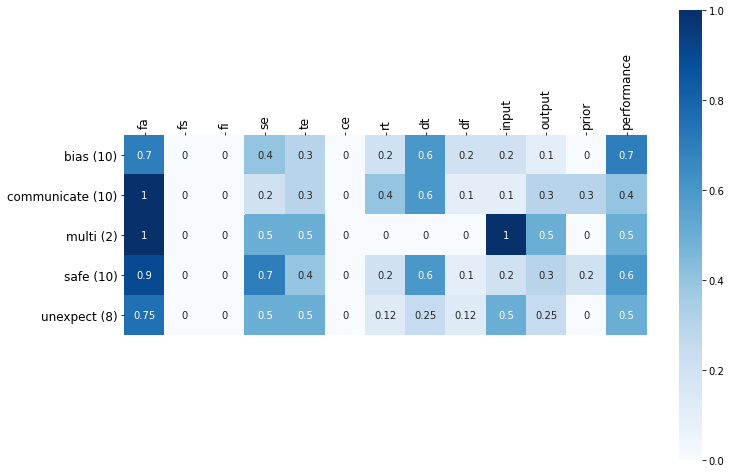

In [4]:
car, car_t = goal_form_mtx(df[df['task']=='car'])


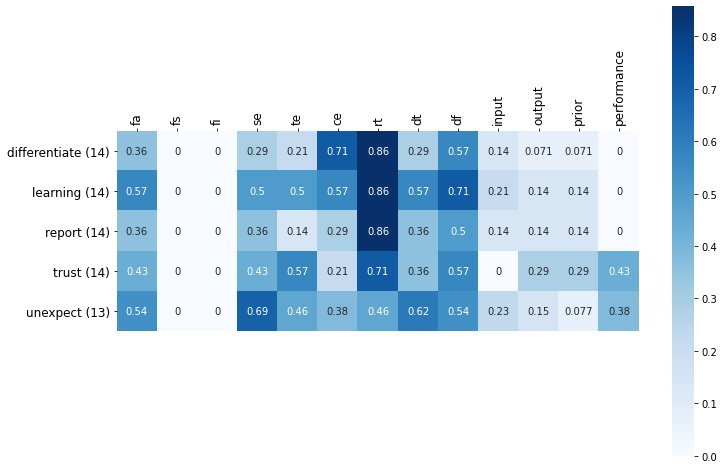

In [5]:
bird, brid_t = goal_form_mtx(df[df['task']=='bird'])


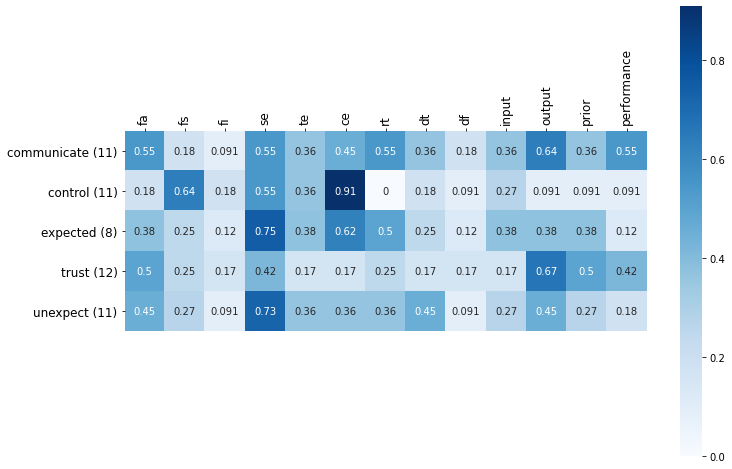

In [6]:
house, house_t = goal_form_mtx(df[df['task']=='house'])


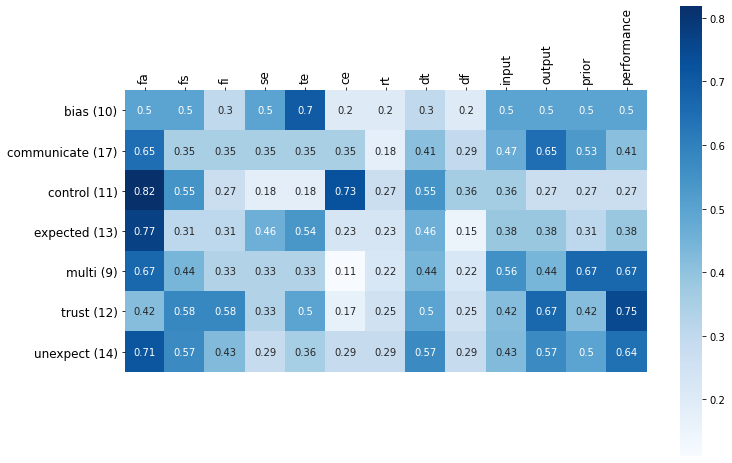

In [7]:
health, health_t = goal_form_mtx(df[df['task']=='health'])


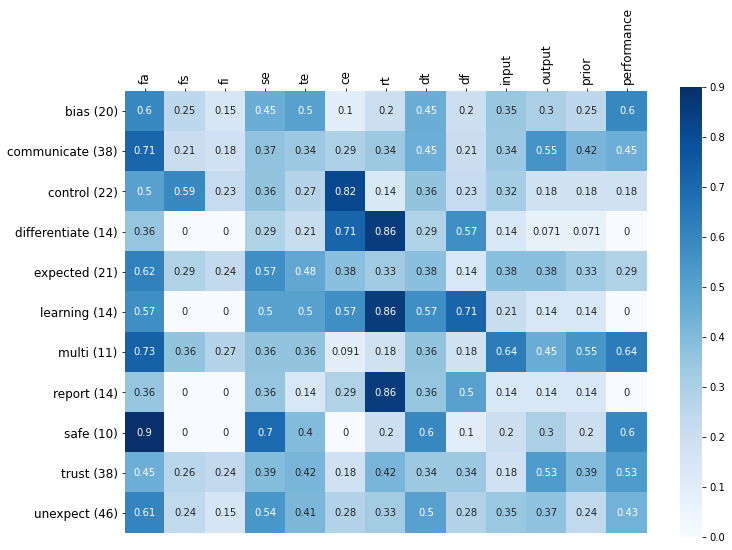

In [8]:
whole, whole_t = goal_form_mtx(df)


In [11]:
goal_dict = {'trust': "Calibrate trust", 'safe': "Ensure Safety", 'bias': "Detect Bias", 
             'unexpect': "Unexpected Prediction: Disagreement with AI", 
             'expected': "Expected Prediction", 'differentiate': "Differentiate Similar Instances", 
             'learning': "Learn from AI", 
             'control': "Improve the Predicted Outcome", 'communicate': "Communicate with Stakeholders", 
             'report': "Generate Reports", 'multi': "Multiple Objectives Trade-Off"}

def goal_mtx(goal, figname = None, cbar = True):
    mtx_lst = {'All': goal_form_mtx(df, plot = False), 
               "House": goal_form_mtx(df[df['task']=='house'], plot = False), 
               "Health": goal_form_mtx(df[df['task']=='health'], plot = False), 
               "Car": goal_form_mtx(df[df['task']=='car'], plot = False), 
               "Bird": goal_form_mtx(df[df['task']=='bird'], plot = False)}
    ticks = []
    new_mtx = pd.DataFrame()
    for mtx_name, (mtx, tick) in mtx_lst.items():
        if goal in mtx:
            new_mtx[mtx_name] = mtx[goal]
            ticks.append("{} ({})".format(mtx_name, tick[goal])) 
    if new_mtx.shape[1] <=2:
        new_mtx = new_mtx.drop(columns=['All'])
        ticks.pop(0)
    new_t = new_mtx.transpose()
    new_t = new_t.rename(columns={'fa':'Feature attribute', "fs": "Feature shape", "fi": "Feature intearction",
                                 "se": "Similar example", 'te': "Typical example", "ce": "Counterfactual example",
                                 "rt": "Rule", 'dt': "Decision tree", "df": "Decision flow chart",
                                 "input": "Input", 'output': "Output", "prior": "Prior", "performance": "Performance"})

    new_t.to_numpy().astype('str')
#     p_label = np.char.add(new_t.to_numpy().astype('str'), purpose_card_order.to_numpy().astype('str'))
    fig, ax = plt.subplots()
    fig.set_size_inches(10, new_mtx.shape[1]*1.5)
    ht=sns.heatmap(new_t, cmap="Blues",annot=True, yticklabels= ticks, square= True,
                  cbar = cbar, cbar_kws={"orientation": "horizontal"}, vmin =0.0, vmax = 1.0)
    ht.set_title('{}'.format(goal_dict[goal]), fontsize= 16)
    ht.set_xticklabels(ht.get_xticklabels(), rotation=90, fontsize=12)
    ht.set_yticklabels(ht.get_yticklabels(), rotation=0, fontsize=12)
    ax.xaxis.tick_top() # x axis on top
    ax.xaxis.set_label_position('top')
    my_colors = ['#F5A623']*3 + ['#F5CF23']*3 + ['#F56723']*3 + ['#4A90E2']*4
    for ticklabel, tickcolor in zip(ht.get_xticklabels(), my_colors):
        ticklabel.set_color(tickcolor)
    if figname:
        fig.savefig('{}_{}.pdf'.format( goal,figname),  bbox_inches='tight')
    


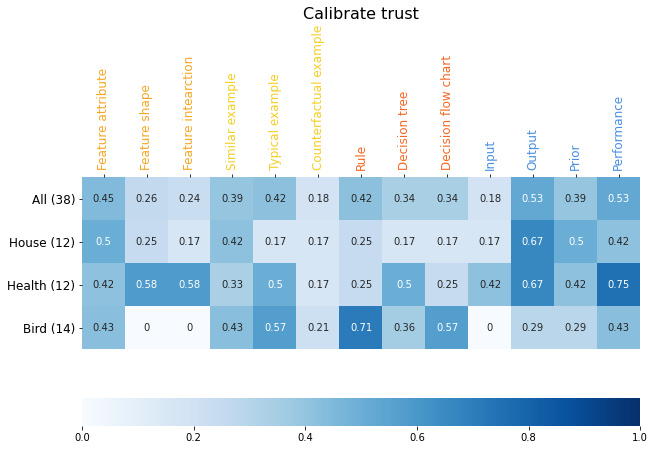

In [12]:
for goal in purpose_col_seq:
    goal_mtx(goal, figname =None, cbar = True)
    break


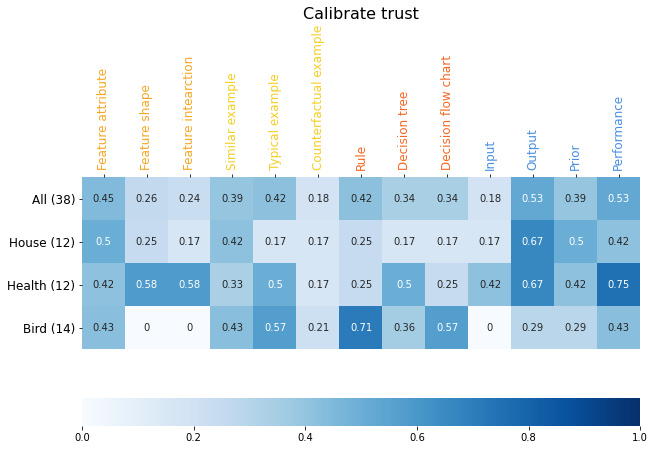

In [13]:
goal_mtx('trust')

In [14]:
car = df[df['task']=='house'] 
car[car['purpose']=='communicate'][card_col]

,1st,2nd,3rd,4th,5th,6th,7th,8th,9th,10th,11th,12th,13th
8,output performance,te fs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,se te,output,rt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,fa,se,input,prior,ce,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,output,prior,performance,fa ce,se te,rt dt df,NaN,NaN,NaN,NaN,NaN,NaN,NaN
133,Output,Input,ce,Performance,fa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
163,output,performance,rt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178,rt,se,ce,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
238,dt,se,output,performance,prior,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
253,input,output se ce,fa rt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
def count_occurance(card_list, purpose):
    """
    if any of the card in card_list occurs, count as 1 occurance
    """
    df_valid = df.loc[~df['1st'].isin(['none', 'x'])]
    df_rank  = df_valid.apply(generate_rank, axis=1)

    table = df_rank[df_rank['purpose']== purpose][card_rank]
    count = 0
    total = table.shape[0]
    for index, row in table.iterrows():
        for card in card_list:
            if row[card] >0:
                count += 1
                break
    return count, total

print(count_occurance(['fa'], 'multi'))

(8, 11)
